Mounted at /content/drive


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
class SimpleTokenizer:
    def __init__(self, vocabulary, max_len=15):
        self.max_len = max_len
        # REMOVE the prepending line. Just use the vocabulary from the file.
        self.words = vocabulary
        self.word2idx = {word: i for i, word in enumerate(self.words)}
        self.idx2word = {i: word for i, word in enumerate(self.words)}
        self.vocab_size = len(self.words)

    def encode(self, text):
        tokens = text.lower().split()
        # Ensure we don't crash on unknown words by defaulting to 0 ([PAD])
        ids = [self.word2idx.get(w, 0) for w in tokens]

        # Add [CLS] token at the start
        if "[CLS]" in self.word2idx:
            ids = [self.word2idx["[CLS]"]] + ids

        # Padding/Truncating to exactly MAX_LEN
        if len(ids) < self.max_len:
            ids += [self.word2idx.get("[PAD]", 0)] * (self.max_len - len(ids))
        else:
            ids = ids[:self.max_len]
        return ids

In [2]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        # Ensure d_model is divisible by num_heads for proper splitting
        assert d_model % num_heads == 0

        # d_k is the dimension of the key, query, and value vectors for each head
        self.d_k = d_model // num_heads

        # Linear layers for Q (Query), K (Key), V (Value) projections
        # These project the input into a higher-dimensional space before splitting into heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        # Final linear layer to project the concatenated output back to d_model dimension
        self.w_o = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        # q, k, v typically have shape: [batch_size, seq_len, d_model]
        batch_size = q.size(0)

        # 1. Linear projections and split into multiple heads
        # Apply linear projections (w_q, w_k, w_v) to the input tensors.
        # Reshape to [batch_size, seq_len, num_heads, d_k] and then transpose to
        # [batch_size, num_heads, seq_len, d_k] for parallel computation across heads.
        Q = self.w_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # 2. Scaled Dot-Product Attention (for each head simultaneously)
        # Calculate attention scores: Q * K^T / sqrt(d_k)
        # Q: [batch, heads, seq_len, d_k], K.transpose(-2, -1): [batch, heads, d_k, seq_len]
        # Result 'scores': [batch, heads, seq_len, seq_len]
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Apply mask (e.g., for padding or future token prevention in decoders)
        # Masking fills positions where mask == 0 with a very small negative number (-1e9)
        # This causes them to become 0 after softmax, effectively ignoring them.
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        # Apply softmax to get attention weights (probabilities) along the last dimension (key sequence length)
        attn = F.softmax(scores, dim=-1)
        # Multiply attention weights by Value vectors
        # attn: [batch, heads, seq_len, seq_len], V: [batch, heads, seq_len, d_k]
        # context: [batch, heads, seq_len, d_k]
        context = torch.matmul(attn, V)

        # 3. Concatenate heads and apply final linear projection
        # Transpose back to [batch_size, seq_len, num_heads, d_k]
        # contiguous() is needed before view() if memory is not contiguous after transpose
        # view to [batch_size, seq_len, d_model] to concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        # Apply final output linear projection (w_o)
        return self.w_o(context)

In [3]:
def create_attention_mask(input_ids, pad_token_id):
    # input_ids shape: [batch_size, seq_len]
    # mask shape: [batch_size, 1, 1, seq_len]
    # We add extra dimensions so it broadcasts across all heads and all query positions
    mask = (input_ids != pad_token_id).unsqueeze(1).unsqueeze(2)
    return mask.int()

In [4]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff) # First linear transformation, expanding the dimension
        self.linear2 = nn.Linear(d_ff, d_model) # Second linear transformation, projecting back to the original dimension
        self.activation = nn.GELU() # BERT specifically uses GELU

    def forward(self, x):
        return self.linear2(self.activation(self.linear1(x)))

In [5]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        # Multi-Head Self-Attention layer: processes input sequences to capture relationships between tokens.
        self.attention = MultiHeadAttention(d_model, num_heads)
        # First Layer Normalization: applied after attention and before the feed-forward network.
        self.norm1 = nn.LayerNorm(d_model)
        # Feed-Forward Network: a simple point-wise fully connected network.
        self.ff = FeedForward(d_model, d_ff)
        # Second Layer Normalization: applied after the feed-forward network.
        self.norm2 = nn.LayerNorm(d_model)
        # Dropout layer: used for regularization to prevent overfitting.
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Pass mask to the MultiHeadAttention layer to ignore padding or future tokens.
        attn_out = self.attention(x, x, x, mask)
        # Add and Norm: apply dropout to attention output, then add it to the original input (residual connection),
        # and finally apply layer normalization (norm1).
        x = self.norm1(x + self.dropout(attn_out))

        # Feed-forward network processing.
        ff_out = self.ff(x)
        # Add and Norm: apply dropout to feed-forward output, add it to the output from the first Add&Norm block,
        # and apply layer normalization (norm2).
        x = self.norm2(x + self.dropout(ff_out))
        return x

In [6]:
class BERT(nn.Module):
    def __init__(self, vocab_size, d_model=8, n_layers=4, num_heads=2, max_len=15):
        super().__init__()
        # Token Embeddings: Converts input token IDs into dense vectors of dimension d_model.
        # This layer learns a unique vector representation for each word in the vocabulary.
        self.token_emb = nn.Embedding(vocab_size, d_model)

        # Positional Embeddings: Adds information about the position of each token in the sequence.
        # Since BERT doesn't use recurrence or convolution, position is explicitly encoded.
        self.pos_emb = nn.Embedding(max_len, d_model)

        # Transformer Encoder Blocks: A stack of 'n_layers' identical EncoderBlock modules.
        # Each block consists of Multi-Head Self-Attention and a Feed-Forward Network.
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_model * 4) for _ in range(n_layers)
        ])

        # Masked Language Model (MLM) Head: A linear layer used for the pre-training task
        # of predicting masked tokens. It projects the final hidden states back to the
        # vocabulary size to get logit scores for each possible token.
        self.mlm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, mask=None):
        # x: Input tensor of token IDs, shape [batch_size, seq_len]
        # mask: Attention mask, shape [batch_size, 1, 1, seq_len], indicating padding tokens.

        batch_size, seq_len = x.size()

        # Create positional indices: A tensor from 0 to seq_len-1 for each item in the batch.
        # This will be used to look up positional embeddings.
        pos = torch.arange(seq_len, device=x.device).expand(batch_size, seq_len)

        # Combine token and positional embeddings:
        # The input tokens are converted to embeddings, and then positional embeddings are added.
        # This gives each token a unique representation that includes its meaning and its position.
        x = self.token_emb(x) + self.pos_emb(pos)

        # Pass the combined embeddings through the stack of Encoder Blocks.
        # Each encoder block applies multi-head self-attention and a feed-forward network,
        # allowing the model to learn complex relationships between tokens.
        for layer in self.layers:
            x = layer(x, mask)

        # FIX: Return x (the 8-dim hidden states)
        # The final output 'x' from the encoder stack represents the contextualized
        # 8-dimensional hidden states for each token in the sequence.
        # This is typically used for downstream tasks like classification or similarity.
        # The `self.mlm_head(x)` would be used specifically for the Masked Language Modeling task
        # to predict the original tokens, but here we return the hidden states directly.
        return x

In [7]:
from google.colab import drive
 #mounting drive in order to access the csv file which contains all the data
drive.mount('/content/drive')
embed_path="/content/drive/MyDrive/FinalProjectYodDaled/MiniSBERT/minibert_emb_4categories.pth"
word_path="/content/drive/MyDrive/FinalProjectYodDaled/MiniSBERT/miniBERT_categorized_words.csv"
vocab_path="/content/drive/MyDrive/FinalProjectYodDaled/MiniSBERT/vocab3.json"

Mounted at /content/drive


In [8]:
import torch
import pandas as pd
import json
import numpy as np


# 1. SETUP PARAMETERS
# These must match exactly how you trained the model in the notebook
D_MODEL = 8
NUM_HEADS = 2
MAX_LEN = 15
VOCAB_PATH = vocab_path
MODEL_WEIGHTS = embed_path
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# 2. LOAD VOCAB AND INITIALIZE TOKENIZER
with open(VOCAB_PATH, 'r') as f:
    vocab = json.load(f)

tokenizer = SimpleTokenizer(vocab, max_len=MAX_LEN)

# 3. INITIALIZE AND LOAD THE MINI-BERT MODEL
model = BERT(
    vocab_size=len(vocab),
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    max_len=MAX_LEN
).to(DEVICE)

# Load the weights from your training
model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
model.eval() # Set to evaluation mode

# 4. PREPARE THE DATAFRAME

df = pd.read_csv(word_path)

def get_embedding(text):
    """
    Function to convert a single English word into
    an 8-dimension vector using the mini-BERT white box.
    """
    # Convert text to numerical IDs
    ids = torch.tensor([tokenizer.encode(text)]).to(DEVICE)

    with torch.no_grad():
        # Get hidden states from BERT (Shape: [1, max_len, d_model])
        hidden_states = model(ids)

        # Extract the [CLS] token (first token) as the word embedding
        # We use .cpu().numpy() to make it compatible with Pandas/Numpy
        embedding = hidden_states[0, 0, :].cpu().numpy()

    return embedding

# 5. EXECUTE EMBEDDINGS
print("Generating embeddings for 'word' column...")

# Apply the function and store as a new column
df['embedding'] = df['word'].apply(get_embedding)

# 6. VIEW RESULTS
print(df.head())

# Optional: If you want to see the 8 numbers as separate columns
embedding_cols = pd.DataFrame(df['embedding'].tolist(), columns=[f'dim_{i}' for i in range(D_MODEL)])
df_final = pd.concat([df['word'], embedding_cols], axis=1)

print("\nFlattened View:")
print(df_final.head())

Generating embeddings for 'word' column...
         word  category                                          embedding
0       apple         0  [-0.672421, -3.950068, 1.8564788, -3.1787477, ...
1      banana         0  [-0.6737437, -3.9144537, 1.8255204, -3.2052426...
2      orange         0  [-0.68898344, -3.9466407, 1.7899193, -3.166840...
3       mango         0  [-0.68643993, -3.9422834, 1.8082558, -3.170741...
4  strawberry         0  [-0.7087515, -3.8893657, 1.7422403, -3.1946957...

Flattened View:
         word     dim_0     dim_1     dim_2     dim_3     dim_4     dim_5  \
0       apple -0.672421 -3.950068  1.856479 -3.178748 -6.212205  5.510981   
1      banana -0.673744 -3.914454  1.825520 -3.205243 -6.193838  5.538463   
2      orange -0.688983 -3.946641  1.789919 -3.166841 -6.168583  5.513486   
3       mango -0.686440 -3.942283  1.808256 -3.170742 -6.180405  5.515003   
4  strawberry -0.708751 -3.889366  1.742240 -3.194696 -6.130228  5.552225   

      dim_6     dim_7  
0  

In [9]:
embeddings = df['embedding'].tolist()

X = torch.tensor(embeddings).float() #tensor which has the concept as an embedded vector
y = torch.tensor(df['category'].values).long() #tensor which has the label values as tensor


/tmp/ipykernel_4535/3094188597.py:3: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.tensor(embeddings).float() #tensor which has the concept as an embedded vector


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- 1. PREPARE DATA (The Train-Test Split) ---
# We take 20% of the 1000 words and hide them from the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #seperating the data into 0.8 training data and 0.2 test data

In [11]:

# Define the Architecture
class MindMapClassifier(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=128, num_classes=4):
        """
        input_dim: 384 (Fixed by SBERT output)
        hidden_dim: 128 (Our 'Brain Power' - where patterns are found)
        num_classes: 5 (Your specific categories)
        """
        super(MindMapClassifier, self).__init__()

        # 1. Input Layer -> Hidden Layer
        # Takes 384 features and expands/filters them into 128 patterns
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        #note: this layer creates 49,152 weights which equals: 128*384 every neuron of the input_dim is connected to every input of the hidden_dim

        # 2. Activation Function (ReLU)
        # Allows the model to learn non-linear relationships
        self.relu = nn.ReLU()

        # 3. Dropout Layer
        # Randomly shuts off 20% of neurons during training to prevent memorization
        self.dropout = nn.Dropout(0.2)

        # 4. Hidden Layer -> Output Layer
        # Condenses the 128 patterns into 5 final category scores
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        #note: this layer creates 640 weights which equals: 128*5 every neuron of the hidden_dim is connected to every input of the num_classes

        #How do the weights determine the Loss?
        #Prediction: The model multiplies the input vector (384 numbers) by the first weight matrix. The result is passed through ReLU (which filters out negative values) and then multiplied by the second matrix.
        #Score: In the end, 5 numbers are obtained (Scores).
        #Penalty (Loss): The CrossEntropyLoss function looks at this error. If the weights caused an incorrect prediction, the Loss will be high.
        #Direct effect: The more a particular weight "pushed" the prediction in the wrong direction, the stronger the "correction" it will receive from the optimizer (Adam).
    def forward(self, x):
        # This is the "Forward Pass" - how data flows through the network
        out = self.fc1(x)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


In [12]:
# --- 2. CONFIGURABLE HYPERPARAMETERS ---
HIDDEN_SIZE = 128 #amount of neurons in the hidden layer
DROPOUT = 0.2 #amount of neurons to deactivate in the training phase
#At each training step, the model randomly "turns off" 20% of the neurons in the hidden layer. This forces the remaining weights to not rely on one specific neuron ("genius neuron").
LR = 0.01 #the learning rate of the optimizer
#Step size: How big the step you take down will be. If the LR is too big (e.g. 0.9), you might skip over the valley to the other side. If it is too small (0.0001), it will take you forever to get there.
EPOCHS = 400 #the amount of epochs/ the amount of time going through all of the dataSet and improving weights accordingly

model = MindMapClassifier(input_dim=8, hidden_dim=HIDDEN_SIZE, num_classes=4)
# Re-apply dropout if you changed the class
model.dropout = nn.Dropout(DROPOUT)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Lists to track progress
train_losses, test_losses = [], []
train_accs, test_accs = [], []

In [13]:
# --- 3. THE EXPERIMENTAL LOOP ---
for epoch in range(EPOCHS):
    # --- Training Phase ---
    #this line is to activate the model in training mode
    model.train()
    #this line is to reset the gradient decent step. for each epoch the model checks the weights and updates them, so we need to reset the calculation each epoch to not add to previous "mistake"
    optimizer.zero_grad()

    #these 2 lines represent the forward pass and bring us the resulted loss we have "the error in the model"
    train_outputs = model(X_train)
    train_loss = criterion(train_outputs, y_train)

    #this line are for doing backpropogation it counts how each of the weight contributed for the loss
    train_loss.backward()
    #this line is for updating the weights depending on how much they impacted the loss with optimizer Adam
    optimizer.step()

    # --- Validation Phase (The "Test") ---
    model.eval() # Turn off Dropout
    with torch.no_grad():
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)

        # Calculate Accuracies
        train_acc = (torch.max(train_outputs, 1)[1] == y_train).sum().item() / y_train.size(0)
        test_acc = (torch.max(test_outputs, 1)[1] == y_test).sum().item() / y_test.size(0)

    train_losses.append(train_loss.item())
    test_losses.append(test_loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss {train_loss.item():.4f} | Test Acc {test_acc*100:.1f}%")

Epoch 0: Train Loss 1.5484 | Test Acc 12.5%
Epoch 10: Train Loss 1.3199 | Test Acc 62.5%
Epoch 20: Train Loss 1.4102 | Test Acc 12.5%
Epoch 30: Train Loss 1.3531 | Test Acc 25.0%
Epoch 40: Train Loss 1.3067 | Test Acc 25.0%
Epoch 50: Train Loss 1.2677 | Test Acc 25.0%
Epoch 60: Train Loss 1.2071 | Test Acc 37.5%
Epoch 70: Train Loss 1.1699 | Test Acc 50.0%
Epoch 80: Train Loss 1.0540 | Test Acc 50.0%
Epoch 90: Train Loss 1.0197 | Test Acc 50.0%
Epoch 100: Train Loss 0.9661 | Test Acc 87.5%
Epoch 110: Train Loss 0.8996 | Test Acc 50.0%
Epoch 120: Train Loss 0.8757 | Test Acc 37.5%
Epoch 130: Train Loss 0.8093 | Test Acc 50.0%
Epoch 140: Train Loss 0.7783 | Test Acc 100.0%
Epoch 150: Train Loss 0.6791 | Test Acc 100.0%
Epoch 160: Train Loss 0.6921 | Test Acc 100.0%
Epoch 170: Train Loss 0.6438 | Test Acc 100.0%
Epoch 180: Train Loss 0.6114 | Test Acc 100.0%
Epoch 190: Train Loss 0.5677 | Test Acc 100.0%
Epoch 200: Train Loss 0.5285 | Test Acc 100.0%
Epoch 210: Train Loss 0.5413 | Test Ac

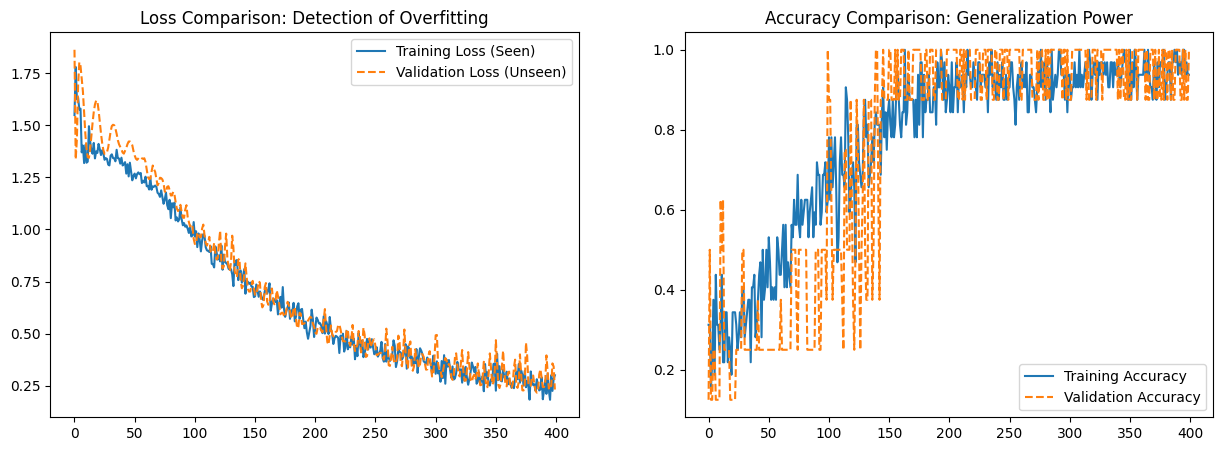

In [14]:
# --- 4. VISUALIZATION ---
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss (Seen)')
plt.plot(test_losses, label='Validation Loss (Unseen)', linestyle='--')
plt.title('Loss Comparison: Detection of Overfitting')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Training Accuracy')
plt.plot(test_accs, label='Validation Accuracy', linestyle='--')
plt.title('Accuracy Comparison: Generalization Power')
plt.legend()
plt.show()

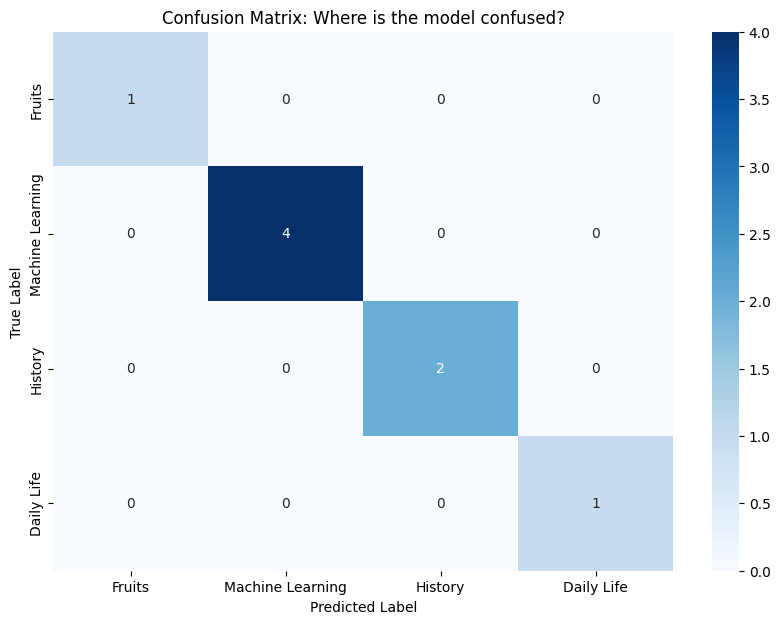

                  precision    recall  f1-score   support

          Fruits       1.00      1.00      1.00         1
Machine Learning       1.00      1.00      1.00         4
         History       1.00      1.00      1.00         2
      Daily Life       1.00      1.00      1.00         1

        accuracy                           1.00         8
       macro avg       1.00      1.00      1.00         8
    weighted avg       1.00      1.00      1.00         8



In [15]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

class_names = [
    "Fruits",
    "Machine Learning",
    "History",
    "Daily Life"
]

# 1. Switch to evaluation mode (Turns off Dropout)
model.eval()

# 2. Get predictions
with torch.no_grad(): # Disable gradient calculation to save memory
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

# 3. Create the Confusion Matrix
cm = confusion_matrix(y_test, predicted)

# 4. Plotting it
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where is the model confused?')
plt.show()

# 5. Print a detailed report
print(classification_report(y_test, predicted, target_names=class_names))

In [ ]:
# Save the 'Brain' of the project
torch.save(model.state_dict(), 'miniBERT_FFNN_classifier_4categories.pth')
print("Model weights saved to miniBERT_FFNN_classifier_4categories.pth")

Model weights saved to miniBERT_FFNN_classifier_4categories.pth
